In [1]:
import torch
from torch import nn
import numpy as np

In [2]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

In [3]:
image_path

PosixPath('data/desert101')

In [4]:
import os

In [5]:
# Datamızı kontrol etmek için bir fonksiyon yazdık.
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories :{len(dirnames)} and {len(filenames)} images in {dirpath}")

In [6]:
check_data(image_path)

# of directories :2 and 1 images in data/desert101
# of directories :4 and 1 images in data/desert101/test
# of directories :0 and 20 images in data/desert101/test/cup_cakes
# of directories :0 and 20 images in data/desert101/test/donuts
# of directories :0 and 20 images in data/desert101/test/baklava
# of directories :0 and 20 images in data/desert101/test/cannoli
# of directories :4 and 1 images in data/desert101/train
# of directories :0 and 80 images in data/desert101/train/cup_cakes
# of directories :0 and 80 images in data/desert101/train/donuts
# of directories :0 and 80 images in data/desert101/train/baklava
# of directories :0 and 80 images in data/desert101/train/cannoli


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [8]:
train_dir

PosixPath('data/desert101/train')

In [9]:
test_dir

PosixPath('data/desert101/test')

In [10]:
from PIL import Image
import random

In [11]:
random.seed(12)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image = random.choice(image_path_list)
img = Image.open(random_image)

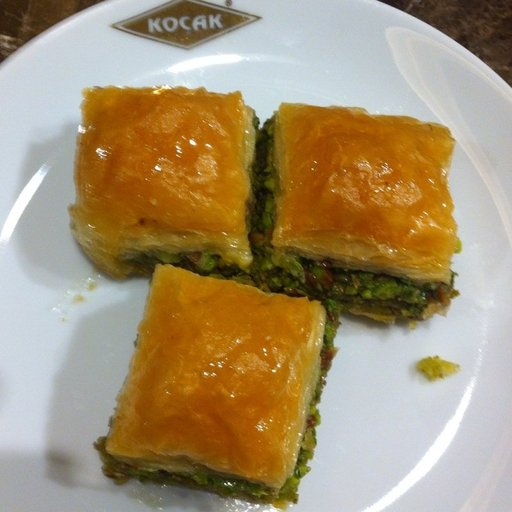

In [12]:
img

In [13]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [14]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

In [15]:
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data  = datasets.ImageFolder(root=test_dir, transform=data_transform)

In [16]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [17]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data/desert101/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [30]:
class_names = train_data.classes
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [19]:
len(train_data), len(test_data)

(316, 77)

In [20]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() # İşlemcinin çekirdekleri

In [21]:
NUM_WORKERS

16

In [22]:
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_datalaoder  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [23]:
train_dataloader.dataset[0][0]

tensor([[[0.6000, 0.5922, 0.5333,  ..., 0.4784, 0.4510, 0.4549],
         [0.6431, 0.5529, 0.5098,  ..., 0.5294, 0.4471, 0.4706],
         [0.6863, 0.5412, 0.5608,  ..., 0.5843, 0.4667, 0.5490],
         ...,
         [0.0510, 0.0314, 0.0196,  ..., 0.1647, 0.1804, 0.2000],
         [0.0549, 0.0196, 0.0118,  ..., 0.2078, 0.1961, 0.1804],
         [0.0627, 0.0392, 0.0471,  ..., 0.1686, 0.1490, 0.1804]],

        [[0.4824, 0.4784, 0.4196,  ..., 0.3451, 0.3137, 0.3216],
         [0.5294, 0.4471, 0.4000,  ..., 0.4078, 0.3333, 0.3569],
         [0.5725, 0.4353, 0.4392,  ..., 0.4549, 0.3412, 0.4078],
         ...,
         [0.7098, 0.2314, 0.1804,  ..., 0.5961, 0.5725, 0.5451],
         [0.7216, 0.1882, 0.1725,  ..., 0.5569, 0.5686, 0.5765],
         [0.7098, 0.7647, 0.7647,  ..., 0.6314, 0.6431, 0.6000]],

        [[0.2118, 0.2157, 0.1686,  ..., 0.0980, 0.0824, 0.0902],
         [0.2314, 0.1804, 0.1490,  ..., 0.1490, 0.1020, 0.1137],
         [0.2510, 0.1725, 0.1529,  ..., 0.1765, 0.1059, 0.

In [113]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape:int, hidden_unit:int, output_layer:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.dense_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_unit *16*16, out_features=output_layer)
        )
    def forward(self,x):
        out = self.conv_block_1(x)
        out = self.conv_block_2(out)
        out = self.dense_layer(out)
        return out

In [114]:
model_0 = DesertClassifier(
    input_shape=3,
    hidden_unit=32,
    output_layer=len(class_names)
)

In [115]:
from torchinfo import summary

In [116]:
summary(model= model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─GELU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─GELU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─GELU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─GELU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [117]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = "cpu"
              ):
    model.to(device)
    model.train() # Modelimizi train moduna alıyoruz.
    
    train_loss = 0 # Train Loss değerlerini tutmak için bir değişken oluşturuyoruz.
    train_acc = 0 # Train Accuracy değerlerini tutmak için bir değişken oluşturuyoruz.

    for batch, (X,y) in enumerate(dataloader): # Batch size gerekli değil burada.
        X,y = X.to(device), y.to(device)
        y_pred = model(X) # Modelimize bir tahminde bulunduruyoruz.
        
        loss = loss_fn(y_pred,y) # Loss değerlerimizi loss_fn ile hesaplıyoruz.
        train_loss += loss.item() # Çıkan loss değerlerini train_loss değişlenine toplayarak atıyoruz.

        # Modelimizi backpropagation yapıyoruz.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Softmax kullanarak modelimize label tahmininde bulunduruyoruz.
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1) 
        
        train_acc += (y_pred_class == y).sum().item() / len(y_pred) # Accuracy değerlerimizi bir değişkende tutuyoruz.

    train_loss /= len(dataloader) # Train Loss değerlerimizi dataloader boyuna bölüyoruz ve ort. elde ediyoruz.
    train_acc /= len(dataloader) # Train Acc değerlerimizi dataloader boyuna bölüyoruz ve ort. elde ediyoruz
    return train_loss, train_acc # Geriye train_loss ve train_acc döndürüyoruz.

In [118]:
def test_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device:torch.device = "cpu"
              ):
    model.to(device)
    model.eval() # Modelimizi test moduna alıyoruz.
    
    test_loss = 0 # test loss'ları tutmak için bir değişken oluşturuyoruz.
    test_acc = 0 # test accuracy'ları tutmak için bir değişken oluşturuyoruz.
    
    with torch.inference_mode(): # inference mode'a aldık.
        for batch, (X,y) in enumerate(dataloader): # batch gerekli değil fakat yine de aldık.
            X,y = X.to(device), y.to(device)
            test_pred = model(X) # modelimize tahmin ettiriyoruz.
            
            loss = loss_fn(test_pred,y) # loss'umuzu loss_fn ile hesaplıyoruz.
            test_loss += loss.item() # loss değerlerimizi test_loss değişkeninde topluyoruz.

            # Softmax activation function ile label tahmin ettiriyoruz.
            test_pred_label = torch.softmax(test_pred,dim=1).argmax(dim=1) 
            
            acc = (test_pred_label == y).sum().item() / len(test_pred) # Calculate accuracy
            test_acc += acc # Accuracy değerlerimizi toplayıp test_acc değişkenine atıyoruz.
            
    test_loss /= len(dataloader) # Test loss değerlerimizi dataloader boyuna bölüyoruz.
    test_acc /= len(dataloader) # Test acc değerlerimizi dataloader boyuna bölüyoruz.
    
    return test_loss, test_acc # Geriye test_loss ve test_acc döndürüyoruz.

In [119]:
def train(model: torch.nn.Module,
               train_dataloader: torch.utils.data.DataLoader,
               test_dataloader: torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
               epochs:int = 10,
               device = "cpu"
              ):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model = model,
                                           dataloader = train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer = optimizer,
                                           device = device
                                          )
        test_loss, test_acc = test_step(model = model,
                                           dataloader = test_dataloader,
                                           loss_fn = loss_fn,
                                           device = device
                                          )
        print(f""" 
        Epoch:{epoch}
        Train Loss : {train_loss:.2f} -  Train Accuracy : {train_acc:.2f}
        Test Loss  : { test_loss:.2f} -  Test Accuracy  : {test_acc:.2f}
        """)
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    return results

In [120]:
NUM_EPOCHS = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model_0.parameters(), lr = 0.001)
model_0_results = train(model= model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_datalaoder,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device = device
                       )

 
        Epoch:0
        Train Loss : 1.39 -  Train Accuracy : 0.23
        Test Loss  : 1.38 -  Test Accuracy  : 0.28
        
 
        Epoch:1
        Train Loss : 1.38 -  Train Accuracy : 0.27
        Test Loss  : 1.39 -  Test Accuracy  : 0.26
        
 
        Epoch:2
        Train Loss : 1.38 -  Train Accuracy : 0.30
        Test Loss  : 1.40 -  Test Accuracy  : 0.25
        
 
        Epoch:3
        Train Loss : 1.35 -  Train Accuracy : 0.34
        Test Loss  : 1.35 -  Test Accuracy  : 0.29
        
 
        Epoch:4
        Train Loss : 1.33 -  Train Accuracy : 0.36
        Test Loss  : 1.36 -  Test Accuracy  : 0.36
        
 
        Epoch:5
        Train Loss : 1.25 -  Train Accuracy : 0.43
        Test Loss  : 1.33 -  Test Accuracy  : 0.31
        
 
        Epoch:6
        Train Loss : 1.33 -  Train Accuracy : 0.35
        Test Loss  : 1.38 -  Test Accuracy  : 0.32
        
 
        Epoch:7
        Train Loss : 1.29 -  Train Accuracy : 0.41
        Test Loss  : 1.34 - 

In [121]:
import matplotlib.pyplot as plt

In [122]:
def plot_loss_curves(results):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]
    epochs = range(len(train_loss))

    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label = "Train Loss")
    plt.plot(epochs, test_loss, label = "Test Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label = "Train Accuracy")
    plt.plot(epochs, test_acc, label = "Test Accuracy")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.show()

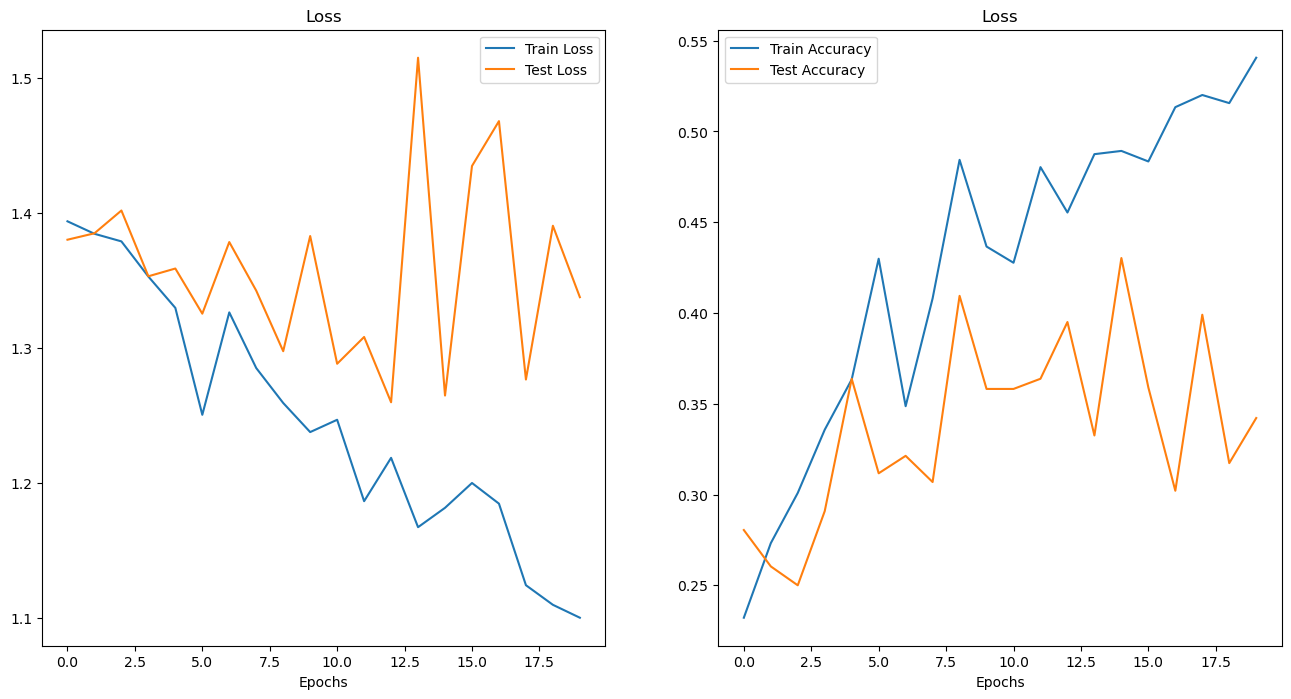

In [123]:
plot_loss_curves(results=model_0_results)

In [124]:
import torchvision 

In [125]:
baklava_img = data_path / "baklava.jpg"
baklava_img

PosixPath('data/baklava.jpg')

In [131]:
single_image = torchvision.io.read_image(str(baklava_img)).type(torch.float32)

In [132]:
single_image

tensor([[[ 46.,  52.,  40.,  ..., 224., 245., 246.],
         [ 36.,  30.,  41.,  ..., 220., 238., 240.],
         [ 44.,  35.,  80.,  ..., 223., 233., 234.],
         ...,
         [227., 225., 223.,  ..., 239., 239., 239.],
         [227., 226., 224.,  ..., 239., 239., 239.],
         [227., 225., 224.,  ..., 239., 239., 239.]],

        [[ 27.,  34.,  22.,  ..., 200., 221., 222.],
         [ 16.,  10.,  20.,  ..., 194., 212., 214.],
         [ 22.,  12.,  56.,  ..., 195., 205., 206.],
         ...,
         [231., 229., 227.,  ..., 250., 250., 250.],
         [231., 230., 228.,  ..., 250., 250., 250.],
         [231., 229., 228.,  ..., 250., 250., 250.]],

        [[ 23.,  24.,   2.,  ..., 140., 161., 162.],
         [  9.,   0.,   0.,  ..., 133., 151., 153.],
         [  8.,   0.,  30.,  ..., 132., 142., 143.],
         ...,
         [232., 230., 228.,  ..., 252., 252., 252.],
         [232., 231., 229.,  ..., 252., 252., 252.],
         [232., 230., 229.,  ..., 252., 252., 252.]]]

In [134]:
single_image /= 255

In [135]:
single_image

tensor([[[0.1804, 0.2039, 0.1569,  ..., 0.8784, 0.9608, 0.9647],
         [0.1412, 0.1176, 0.1608,  ..., 0.8627, 0.9333, 0.9412],
         [0.1725, 0.1373, 0.3137,  ..., 0.8745, 0.9137, 0.9176],
         ...,
         [0.8902, 0.8824, 0.8745,  ..., 0.9373, 0.9373, 0.9373],
         [0.8902, 0.8863, 0.8784,  ..., 0.9373, 0.9373, 0.9373],
         [0.8902, 0.8824, 0.8784,  ..., 0.9373, 0.9373, 0.9373]],

        [[0.1059, 0.1333, 0.0863,  ..., 0.7843, 0.8667, 0.8706],
         [0.0627, 0.0392, 0.0784,  ..., 0.7608, 0.8314, 0.8392],
         [0.0863, 0.0471, 0.2196,  ..., 0.7647, 0.8039, 0.8078],
         ...,
         [0.9059, 0.8980, 0.8902,  ..., 0.9804, 0.9804, 0.9804],
         [0.9059, 0.9020, 0.8941,  ..., 0.9804, 0.9804, 0.9804],
         [0.9059, 0.8980, 0.8941,  ..., 0.9804, 0.9804, 0.9804]],

        [[0.0902, 0.0941, 0.0078,  ..., 0.5490, 0.6314, 0.6353],
         [0.0353, 0.0000, 0.0000,  ..., 0.5216, 0.5922, 0.6000],
         [0.0314, 0.0000, 0.1176,  ..., 0.5176, 0.5569, 0.

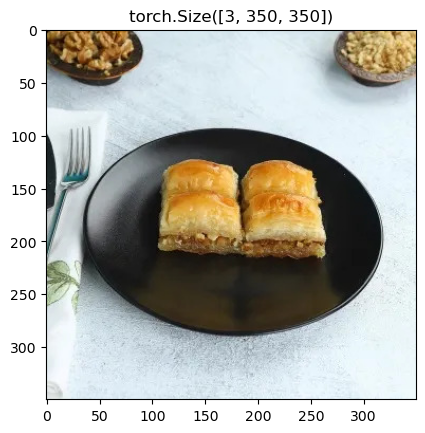

In [141]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)
plt.show()

In [146]:
single_image_transforms = transforms.Compose([
    transforms.Resize(size=(64,64))
])
single_image = single_image_transforms(single_image)

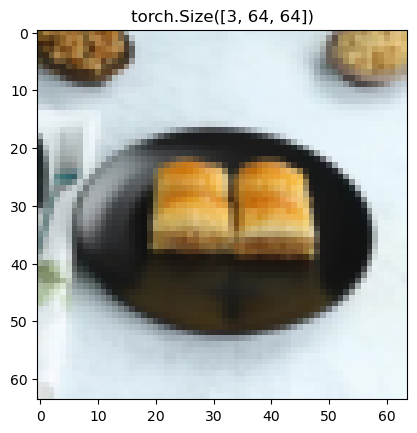

In [148]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)
plt.show()

In [150]:
single_image.shape

torch.Size([3, 64, 64])

In [163]:
single_image = single_image.unsqueeze(dim=0)

In [165]:
model_0.eval()
single_image = single_image.to("cuda" if torch.cuda.is_available() else "cpu")
with torch.inference_mode():
    y_logit = model_0(single_image)
    probs = torch.softmax(y_logit, dim=1)
    pred_idx = torch.argmax(probs,dim=1).item()
print("Predicted Class: "model_0.__class__[])

1
